In [24]:
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch
from torch import nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm
from timeit import default_timer as timer
import random

In [5]:
train_data=datasets.MNIST(root="data1",
                          train=True,
                          download=True,
                          transform=ToTensor())

100%|██████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [02:19<00:00, 70.9kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 114kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 780kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 3.29MB/s]


In [9]:
test_data=datasets.MNIST(root="data1",
                         train=False,
                         download=True,
                         transform=ToTensor())

In [10]:
train_data,test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data1
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data1
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [11]:
len(train_data),len(test_data)

(60000, 10000)

In [12]:
img,label=train_data[0]
img.shape,label

(torch.Size([1, 28, 28]), 5)

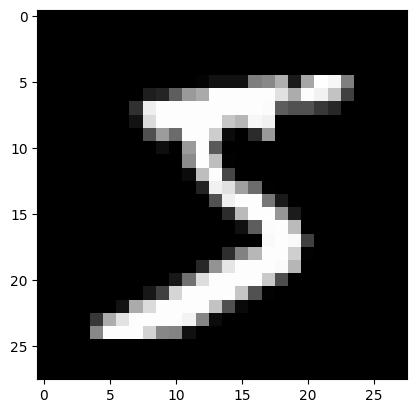

In [16]:
plt.imshow(img.squeeze().numpy(),cmap="gray")

In [39]:
class_names=train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

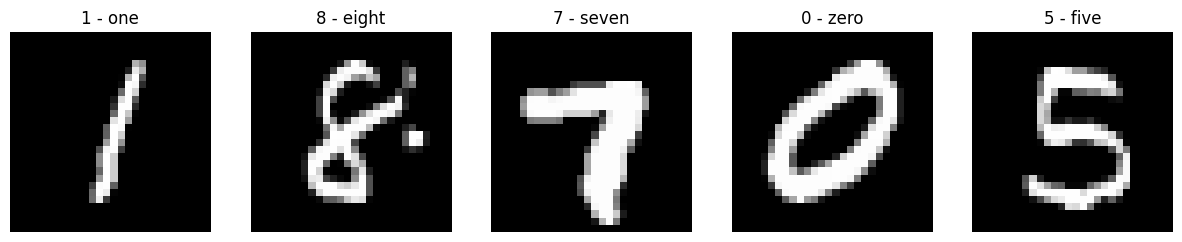

In [41]:
fig,axes=plt.subplots(1,5,figsize=(15,3))

for ax,(img,label) in zip(axes,random.sample(list(test_data),k=5)):
    ax.imshow(img.squeeze().numpy(),cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

In [20]:
train_dataloader=DataLoader(train_data,
                            batch_size=32,
                            shuffle=True)
test_dataloader=DataLoader(test_data,
                            batch_size=32,
                            shuffle=False)

In [21]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1f672949810>,
 <torch.utils.data.dataloader.DataLoader at 0x1f672949f90>)

In [53]:
class cnn(nn.Module):
    def __init__(self,input_shape,output_shape,hidden_layer):
        super().__init__()

        self.block1=nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_layer,
                     kernel_size=3,
                     padding=1,
                     stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_layer,
                      out_channels=hidden_layer,
                     kernel_size=3,
                     padding=1,
                     stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.block2=nn.Sequential(
            nn.Conv2d(in_channels=hidden_layer,
                      out_channels=hidden_layer,
                     kernel_size=3,
                     padding=1,
                     stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_layer,
                      out_channels=hidden_layer,
                     kernel_size=3,
                     padding=1,
                     stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_layer*7*7,
                      out_features=output_shape)
        )

    def forward(self,x):
        return self.classifier(self.block2(self.block1(x)))

In [54]:
def training_pipeline(model,data_loader,loss_func,optimizer):
    training_loss,training_accuracy=0,0
    for x,y in data_loader:
        model.train()
        y_logit=model(x)
        loss=loss_func(y_logit,y)
        training_loss+=loss
        training_accuracy+=accuracy_score(y,y_logit.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    training_loss/=len(data_loader)
    training_accuracy/=len(data_loader)
    print(f"Training loss is {training_loss}")
    print(f"Training accuracy is {training_accuracy}")

In [55]:
def testing_pipeline(model,data_loader,loss_func):
    loss,accuracy=0,0
    model.eval()
    with torch.inference_mode():
        for x,y in data_loader:
            y_logit=model(x)
            loss+=loss_func(y_logit,y)
            accuracy+=accuracy_score(y,y_logit.argmax(dim=1))
        loss/=len(data_loader)
        accuracy/=len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": accuracy}

In [56]:
torch.manual_seed(18)
model=cnn(1,len(class_names),10)
model

cnn(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [57]:
loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [58]:
epochs=3
start_time=timer()
for epoch in tqdm(range(epochs)):
    training_pipeline(model,train_dataloader,loss_func,optimizer)
end_time=timer()
print(f"Time taken to train the model is {end_time-start_time}.")

  0%|          | 0/3 [00:00<?, ?it/s]

Training loss is 1.3899400234222412
Training accuracy is 0.5160666666666667
Training loss is 0.15412026643753052
Training accuracy is 0.9535666666666667
Training loss is 0.1036880686879158
Training accuracy is 0.9678666666666667
Time taken to train the model is 168.90031669999007.


In [59]:
model_results=testing_pipeline(model,test_dataloader,loss_func)
model_results

{'model_name': 'cnn',
 'model_loss': 0.08864960074424744,
 'model_acc': 0.9717452076677316}

In [69]:
x=test_data.data.unsqueeze(1)
y_true=test_data.targets

In [70]:
x=x.float()/255

In [71]:
y_logit=model(x)

In [72]:
y_pred=y_logit.argmax(dim=1)

In [74]:
cm=confusion_matrix(y_true,y_pred)
cm

array([[ 968,    0,    1,    0,    1,    1,    5,    1,    3,    0],
       [   0, 1118,    2,    3,    1,    0,    2,    1,    8,    0],
       [   4,    1, 1005,   10,    1,    0,    0,    4,    7,    0],
       [   1,    0,    1,  998,    0,    3,    0,    4,    3,    0],
       [   2,    0,    1,    1,  963,    0,    3,    4,    2,    6],
       [   1,    0,    2,   25,    0,  857,    3,    0,    2,    2],
       [   4,    3,    0,    1,    6,    4,  938,    0,    2,    0],
       [   1,    2,    9,    6,    0,    0,    0, 1005,    2,    3],
       [   5,    0,    6,   21,    6,    7,    5,    9,  913,    2],
       [   4,    5,    0,   20,   11,    6,    0,    7,    4,  952]])

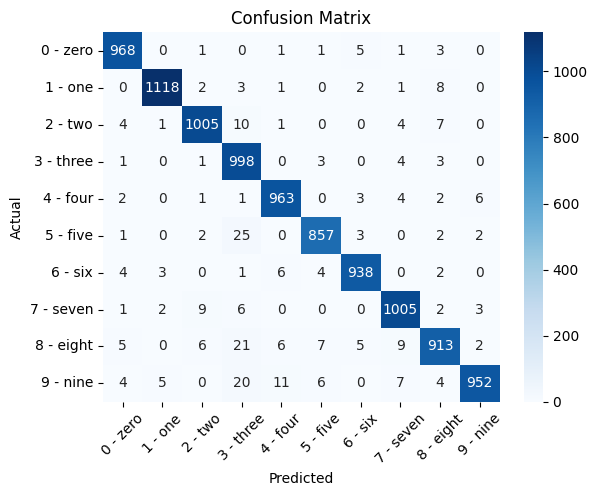

In [75]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()